### Import Libraries

In [1]:

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

try:
    from ultralytics import YOLO
    YOLO_AVAILABLE = True
except Exception as error:
    YOLO = None
    YOLO_AVAILABLE = False
    print("Ultralytics is not available. YOLO evaluation will be skipped safely.")

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IMAGE_SIZE = 224
EVAL_BATCH_SIZE = 32

print("LIBRARIES LOADED")
print("TensorFlow:", tf.__version__)
print("YOLO Library Available:", YOLO_AVAILABLE)


LIBRARIES LOADED
TensorFlow: 2.21.0
YOLO Library Available: True


### Device Check

In [2]:

gpu_devices = tf.config.list_physical_devices("GPU")
print("DEVICE CHECK")
print("GPU Available:", bool(gpu_devices))
print("Device:", "GPU" if gpu_devices else "CPU")


DEVICE CHECK
GPU Available: False
Device: CPU


### Project Paths

In [3]:

NOTEBOOK_ROOT = Path(
    r"E:\programming languages\DJANGO PROJECT\SmartAgriVision"
    r"\SmartAgriVision\AgriVision\AI\notebooks"
)

CLEANED_DATASET_ROOT = NOTEBOOK_ROOT / "Cleaned_Dataset"
PREPROCESSED_DATASET_ROOT = NOTEBOOK_ROOT / "Preprocessed_Dataset"

CNN_DATASET_ROOT = NOTEBOOK_ROOT / "CNN_Classification_Dataset"
CNN_MODEL_ROOT = NOTEBOOK_ROOT / "CNN_Models"

YOLO_DATASET_CANDIDATES = [
    NOTEBOOK_ROOT / "YOLO_Classification_Dataset",
    NOTEBOOK_ROOT / "YOLO_Classification_Dataset_Balanced",
    NOTEBOOK_ROOT / "YOLO_Dataset",
]

YOLO_MODEL_ROOT = NOTEBOOK_ROOT / "YOLO_Models"
EVALUATION_ROOT = NOTEBOOK_ROOT / "Model_Evaluation_Results"
EVALUATION_ROOT.mkdir(parents=True, exist_ok=True)

print("PATH EXISTENCE CHECK")
paths_to_check = {
    "Cleaned Dataset": CLEANED_DATASET_ROOT,
    "Preprocessed Dataset": PREPROCESSED_DATASET_ROOT,
    "CNN Dataset": CNN_DATASET_ROOT,
    "CNN Models": CNN_MODEL_ROOT,
    "YOLO Models": YOLO_MODEL_ROOT,
    "Evaluation Output": EVALUATION_ROOT,
}
for name, path in paths_to_check.items():
    print(f"{name}: {path.exists()}")


PATH EXISTENCE CHECK
Cleaned Dataset: True
Preprocessed Dataset: True
CNN Dataset: True
CNN Models: True
YOLO Models: True
Evaluation Output: True


### Model Candidates

In [4]:

CNN_MODEL_CANDIDATES = [
    CNN_MODEL_ROOT / "best_cnn_model.keras",
    CNN_MODEL_ROOT / "final_cnn_model.keras",
    CNN_MODEL_ROOT / "best_cnn_model.h5",
    CNN_MODEL_ROOT / "final_cnn_model.h5",
]

YOLO_MODEL_CANDIDATES = [
    YOLO_MODEL_ROOT / "training_runs" / "smartagrivision_yolo" / "weights" / "best.pt",
    YOLO_MODEL_ROOT / "training_runs" / "smartagrivision_yolo" / "weights" / "last.pt",
    YOLO_MODEL_ROOT / "best.pt",
    YOLO_MODEL_ROOT / "classification_runs" / "smartagrivision_yolo_classification" / "weights" / "best.pt",
    YOLO_MODEL_ROOT / "classification_runs" / "smartagrivision_yolo_classification" / "weights" / "last.pt",
]

print("MODEL CANDIDATES")
for p in CNN_MODEL_CANDIDATES:
    print("CNN:", p, "| Exists:", p.exists())
for p in YOLO_MODEL_CANDIDATES:
    print("YOLO:", p, "| Exists:", p.exists())


MODEL CANDIDATES
CNN: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.keras | Exists: True
CNN: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\final_cnn_model.keras | Exists: True
CNN: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.h5 | Exists: False
CNN: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\final_cnn_model.h5 | Exists: False
YOLO: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\training_runs\smartagrivision_yolo\weights\best.pt | Exists: False
YOLO: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\training_runs\smartagrivision_yolo\weights\last.pt | Exists: False
YOLO: E:\programming languages\

### Load Evaluation Metadata

In [5]:

metadata_candidates = [
    PREPROCESSED_DATASET_ROOT / "metadata" / "image_metadata_preprocessed.csv",
    PREPROCESSED_DATASET_ROOT / "image_metadata_preprocessed.csv",
    NOTEBOOK_ROOT / "Preprocessed_Data" / "metadata" / "image_metadata_preprocessed.csv",
    NOTEBOOK_ROOT / "Preprocessed_Data" / "image_metadata_preprocessed.csv",
]

metadata_path = next((p for p in metadata_candidates if p.exists()), None)

print("METADATA SEARCH")
print("Found:", metadata_path if metadata_path else "None")

if metadata_path is None:
    raise FileNotFoundError(
        "image_metadata_preprocessed.csv was not found. "
        "Run 05_Image_Preprocessing.ipynb first."
    )

image_metadata_df = pd.read_csv(metadata_path)

print("METADATA LOADED")
print("Rows:", f"{len(image_metadata_df):,}")
print("Columns:", len(image_metadata_df.columns))
print("Shape:", image_metadata_df.shape)

print("\nMETADATA STRUCTURE")
for i, col in enumerate(image_metadata_df.columns, 1):
    print(f"{i}. {col}")

print("\nMISSING VALUES")
display(image_metadata_df.isnull().sum())


METADATA SEARCH
Found: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Preprocessed_Dataset\metadata\image_metadata_preprocessed.csv
METADATA LOADED
Rows: 294,695
Columns: 8
Shape: (294695, 8)

METADATA STRUCTURE
1. Dataset
2. Split
3. Class
4. Image_Path
5. Filename
6. Label
7. Encoded_Label
8. Processed_Split

MISSING VALUES


Dataset            0
Split              0
Class              0
Image_Path         0
Filename           0
Label              0
Encoded_Label      0
Processed_Split    0
dtype: int64

### Dataset Summary

In [6]:

print("DATASET SUMMARY")
print("Datasets:", image_metadata_df["Dataset"].nunique() if "Dataset" in image_metadata_df.columns else "N/A")
print("Classes:", image_metadata_df["Class"].nunique() if "Class" in image_metadata_df.columns else "N/A")
print("Images:", f"{len(image_metadata_df):,}")

if "Processed_Split" in image_metadata_df.columns:
    print("\nSPLIT DISTRIBUTION")
    display(
        image_metadata_df["Processed_Split"]
        .astype(str)
        .str.strip()
        .str.lower()
        .value_counts()
        .rename_axis("Split")
        .reset_index(name="Images")
    )


DATASET SUMMARY
Datasets: 4
Classes: 82
Images: 294,695

SPLIT DISTRIBUTION


,Split,Images
0,unsplit,182942
1,train,87937
2,validation,20564
3,test,3252


### Resolve Image Paths

In [7]:

def normalize_split(value):
    value = str(value).strip().lower()
    mapping = {
        "train": "train",
        "training": "train",
        "val": "val",
        "valid": "val",
        "validation": "val",
        "test": "test",
        "testing": "test",
    }
    return mapping.get(value, "invalid")

def resolve_image_path(row):
    candidates = []

    for col in [
        "Resolved_Image_Path",
        "Processed_Image_Path",
        "Preprocessed_Image_Path",
        "Image_Path",
        "Processed_Path",
        "Path",
    ]:
        if col in row.index:
            value = row[col]
            if pd.notna(value) and str(value).strip():
                candidates.append(Path(str(value).strip()))

    for candidate in candidates:
        if candidate.is_file():
            return str(candidate)

    return None

eval_df = image_metadata_df.copy()

split_column = (
    "Processed_Split"
    if "Processed_Split" in eval_df.columns
    else "Split"
)

eval_df["Evaluation_Split"] = eval_df[split_column].map(normalize_split)

eval_df["Resolved_Eval_Path"] = eval_df.apply(
    resolve_image_path,
    axis=1
)

print("IMAGE PATH RESOLUTION")
print("Resolved:", eval_df["Resolved_Eval_Path"].notna().sum())
print("Missing:", eval_df["Resolved_Eval_Path"].isna().sum())


IMAGE PATH RESOLUTION
Resolved: 294695
Missing: 0


### Evaluation Dataset Validation

In [8]:

test_eval_df = eval_df[
    (eval_df["Evaluation_Split"] == "test")
    & eval_df["Resolved_Eval_Path"].notna()
].copy()

print("CNN EVALUATION DATA CHECK")
print("Test images available:", f"{len(test_eval_df):,}")
print("Test classes:", test_eval_df["Class"].nunique() if not test_eval_df.empty else 0)

if not test_eval_df.empty:
    class_distribution = (
        test_eval_df["Class"]
        .value_counts()
        .rename_axis("Class")
        .reset_index(name="Images")
    )
    display(class_distribution.head(20))

CNN_METADATA_TEST_READY = not test_eval_df.empty

print("CNN Metadata Test Ready:", CNN_METADATA_TEST_READY)


CNN EVALUATION DATA CHECK
Test images available: 3,252
Test classes: 42


,Class,Images
0,Bean,200
1,Bitter_Gourd,200
2,Bottle_Gourd,200
3,Brinjal,200
4,Broccoli,200
5,Cabbage,200
6,Capsicum,200
7,Carrot,200
8,Cauliflower,200
9,Cucumber,200


CNN Metadata Test Ready: True


### CNN Dataset Folder Check

In [9]:

CNN_SPLIT_DIRS = {
    "train": CNN_DATASET_ROOT / "train",
    "val": CNN_DATASET_ROOT / "val",
    "test": CNN_DATASET_ROOT / "test",
}

cnn_structure_rows = []

for split, split_path in CNN_SPLIT_DIRS.items():
    class_dirs = []
    image_count = 0

    if split_path.exists():
        class_dirs = [p for p in split_path.iterdir() if p.is_dir()]
        for class_dir in class_dirs:
            image_count += sum(
                1 for p in class_dir.rglob("*")
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
            )

    cnn_structure_rows.append({
        "Split": split,
        "Class_Folders": len(class_dirs),
        "Images": image_count,
        "Ready": len(class_dirs) > 0 and image_count > 0,
    })

cnn_structure_df = pd.DataFrame(cnn_structure_rows)

print("CNN DATASET FOLDER CHECK")
display(cnn_structure_df)

CNN_FOLDER_READY = bool(cnn_structure_df["Ready"].all())
print("CNN Folder Dataset Ready:", CNN_FOLDER_READY)
print("Note: CNN evaluation does NOT depend on this folder dataset.")


CNN DATASET FOLDER CHECK


,Split,Class_Folders,Images,Ready
0,train,82,90482,True
1,val,54,22468,True
2,test,43,5157,True


CNN Folder Dataset Ready: True
Note: CNN evaluation does NOT depend on this folder dataset.


### Load Trained CNN Model

In [10]:

cnn_model_path = next(
    (p for p in CNN_MODEL_CANDIDATES if p.exists()),
    None
)

cnn_model = None

print("CNN MODEL SEARCH")
print("Selected:", cnn_model_path if cnn_model_path else "None")

if cnn_model_path is not None:
    try:
        cnn_model = keras.models.load_model(cnn_model_path)
        print("CNN MODEL LOADED")
        print("Input Shape:", cnn_model.input_shape)
        print("Output Shape:", cnn_model.output_shape)
        print("Parameters:", f"{cnn_model.count_params():,}")
    except Exception as error:
        print("CNN MODEL LOAD FAILED")
        print(error)
else:
    print("CNN MODEL NOT FOUND")


CNN MODEL SEARCH
Selected: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.keras
CNN MODEL LOADED
Input Shape: (None, 128, 128, 3)
Output Shape: (None, 82)
Parameters: 475,282


### Determine CNN Class Mapping

In [11]:

if "Encoded_Label" in test_eval_df.columns:
    class_mapping_df = (
        test_eval_df[["Class", "Encoded_Label"]]
        .drop_duplicates()
        .copy()
    )

    class_mapping_df["Encoded_Label"] = pd.to_numeric(
        class_mapping_df["Encoded_Label"],
        errors="coerce"
    )

    class_mapping_df = (
        class_mapping_df
        .dropna()
        .sort_values("Encoded_Label")
    )

    model_class_names = class_mapping_df["Class"].tolist()
    metadata_label_map = dict(
        zip(
            class_mapping_df["Class"],
            class_mapping_df["Encoded_Label"].astype(int)
        )
    )
else:
    model_class_names = sorted(test_eval_df["Class"].unique().tolist())
    metadata_label_map = {
        name: i for i, name in enumerate(model_class_names)
    }

print("CNN CLASS MAPPING")
print("Classes available in test metadata:", len(model_class_names))
print("Model output classes:", cnn_model.output_shape[-1] if cnn_model is not None else "N/A")

if cnn_model is not None and cnn_model.output_shape[-1] != len(model_class_names):
    print(
        "WARNING: model output class count and metadata class count differ. "
        "Only evaluation-compatible rows will be used."
    )


CNN CLASS MAPPING
Classes available in test metadata: 42
Model output classes: 82


### Build Fast Metadata-Based CNN Evaluation Loader

In [12]:

class MetadataImageSequence(keras.utils.Sequence):
    def __init__(
        self,
        dataframe,
        class_to_index,
        image_size=(224, 224),
        batch_size=32,
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.class_to_index = class_to_index
        self.image_size = image_size
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch = self.df.iloc[
            index * self.batch_size:
            min((index + 1) * self.batch_size, len(self.df))
        ]

        images = []
        labels = []

        for _, row in batch.iterrows():
            try:
                with Image.open(row["Resolved_Eval_Path"]) as img:
                    img = img.convert("RGB")
                    img = img.resize(self.image_size)
                    arr = np.asarray(img, dtype=np.float32) / 255.0

                images.append(arr)
                labels.append(self.class_to_index[row["Class"]])

            except Exception:
                # Invalid images are skipped by marking them with a safe dummy.
                images.append(np.zeros(
                    (*self.image_size, 3),
                    dtype=np.float32
                ))
                labels.append(self.class_to_index[row["Class"]])

        return np.asarray(images, dtype=np.float32), np.asarray(labels, dtype=np.int32)

cnn_class_to_index = metadata_label_map

compatible_test_df = test_eval_df[
    test_eval_df["Class"].isin(cnn_class_to_index)
].copy()

if cnn_model is not None:
    output_classes = int(cnn_model.output_shape[-1])
    compatible_test_df = compatible_test_df[
        compatible_test_df["Class"].map(cnn_class_to_index) < output_classes
    ].copy()

cnn_test_sequence = None

if cnn_model is not None and not compatible_test_df.empty:
    cnn_test_sequence = MetadataImageSequence(
        compatible_test_df,
        cnn_class_to_index,
        image_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=EVAL_BATCH_SIZE,
    )

print("CNN TEST LOADER")
print("Usable test images:", f"{len(compatible_test_df):,}")
print("Batches:", len(cnn_test_sequence) if cnn_test_sequence else 0)


CNN TEST LOADER
Usable test images: 3,252
Batches: 102


### CNN Test Evaluation

In [13]:

cnn_evaluation = {
    "loss": np.nan,
    "accuracy": np.nan,
}

if cnn_model is not None and cnn_test_sequence is not None:
    try:
        values = cnn_model.evaluate(
            cnn_test_sequence,
            verbose=1
        )

        cnn_evaluation["loss"] = float(values[0])

        # Keras metric order may vary. Prefer named metrics when available.
        metric_names = list(cnn_model.metrics_names)

        if "accuracy" in metric_names:
            acc_index = metric_names.index("accuracy")
            cnn_evaluation["accuracy"] = float(values[acc_index])
        else:
            print("Accuracy metric name not found; accuracy will be computed from predictions.")

        print("CNN TEST EVALUATION")
        print("Test Loss:", cnn_evaluation["loss"])

    except Exception as error:
        print("CNN EVALUATION FAILED")
        print(error)
else:
    print("CNN EVALUATION SKIPPED SAFELY")


102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 497ms/step - accuracy: 0.7208 - loss: 1.0888
Accuracy metric name not found; accuracy will be computed from predictions.
CNN TEST EVALUATION
Test Loss: 1.088813304901123


### Generate CNN Predictions

In [14]:

cnn_probabilities = None
cnn_predictions = None
cnn_true_labels = None

if cnn_model is not None and cnn_test_sequence is not None:
    try:
        cnn_probabilities = cnn_model.predict(
            cnn_test_sequence,
            verbose=1
        )

        cnn_predictions = np.argmax(
            cnn_probabilities,
            axis=1
        )

        cnn_true_labels = compatible_test_df["Class"].map(
            cnn_class_to_index
        ).to_numpy(dtype=np.int32)

        if cnn_evaluation["accuracy"] is np.nan or np.isnan(cnn_evaluation["accuracy"]):
            cnn_evaluation["accuracy"] = accuracy_score(
                cnn_true_labels,
                cnn_predictions
            )

        print("CNN PREDICTIONS GENERATED")
        print("Samples:", f"{len(cnn_true_labels):,}")

    except Exception as error:
        print("CNN PREDICTION FAILED")
        print(error)
else:
    print("CNN PREDICTIONS SKIPPED")


102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 481ms/step
CNN PREDICTIONS GENERATED
Samples: 3,252


### CNN Precision, Recall & F1

In [15]:

cnn_precision = np.nan
cnn_recall = np.nan
cnn_f1 = np.nan

if cnn_predictions is not None:
    cnn_precision = precision_score(
        cnn_true_labels,
        cnn_predictions,
        average="macro",
        zero_division=0,
    )

    cnn_recall = recall_score(
        cnn_true_labels,
        cnn_predictions,
        average="macro",
        zero_division=0,
    )

    cnn_f1 = f1_score(
        cnn_true_labels,
        cnn_predictions,
        average="macro",
        zero_division=0,
    )

    print("CNN METRICS")
    print("Accuracy:", f"{cnn_evaluation['accuracy']:.4f}")
    print("Precision:", f"{cnn_precision:.4f}")
    print("Recall:", f"{cnn_recall:.4f}")
    print("F1-Score:", f"{cnn_f1:.4f}")
else:
    print("CNN METRICS NOT AVAILABLE")


CNN METRICS
Accuracy: 0.7208
Precision: 0.2570
Recall: 0.2345
F1-Score: 0.2262


### CNN Classification Report

In [16]:

cnn_report_df = pd.DataFrame()

if cnn_predictions is not None:
    class_names_for_report = [
        name for name, idx in sorted(
            cnn_class_to_index.items(),
            key=lambda x: x[1]
        )
        if idx < cnn_model.output_shape[-1]
    ]

    labels_for_report = list(range(len(class_names_for_report)))

    cnn_report = classification_report(
        cnn_true_labels,
        cnn_predictions,
        labels=labels_for_report,
        target_names=class_names_for_report,
        output_dict=True,
        zero_division=0,
    )

    cnn_report_df = pd.DataFrame(cnn_report).transpose()

    print("CNN CLASSIFICATION REPORT")
    display(cnn_report_df)
else:
    print("CNN CLASSIFICATION REPORT NOT AVAILABLE")


CNN CLASSIFICATION REPORT


,precision,recall,f1-score,support
Apple_Scab_Leaf,0.000000,0.000000,0.000000,10.0
Apple_leaf,0.000000,0.000000,0.000000,0.0
Apple_rust_leaf,0.000000,0.000000,0.000000,0.0
Bean,0.000000,0.000000,0.000000,0.0
Bell_pepper_leaf,0.000000,0.000000,0.000000,0.0
Bell_pepper_leaf_spot,0.000000,0.000000,0.000000,9.0
Bitter_Gourd,0.250000,0.500000,0.333333,10.0
Blueberry_leaf,1.000000,0.495000,0.662207,200.0
Bottle_Gourd,0.000000,0.000000,0.000000,8.0
Brinjal,0.000000,0.000000,0.000000,9.0


### CNN Confusion Matrix

CNN CONFUSION MATRIX
Shape: (63, 63)


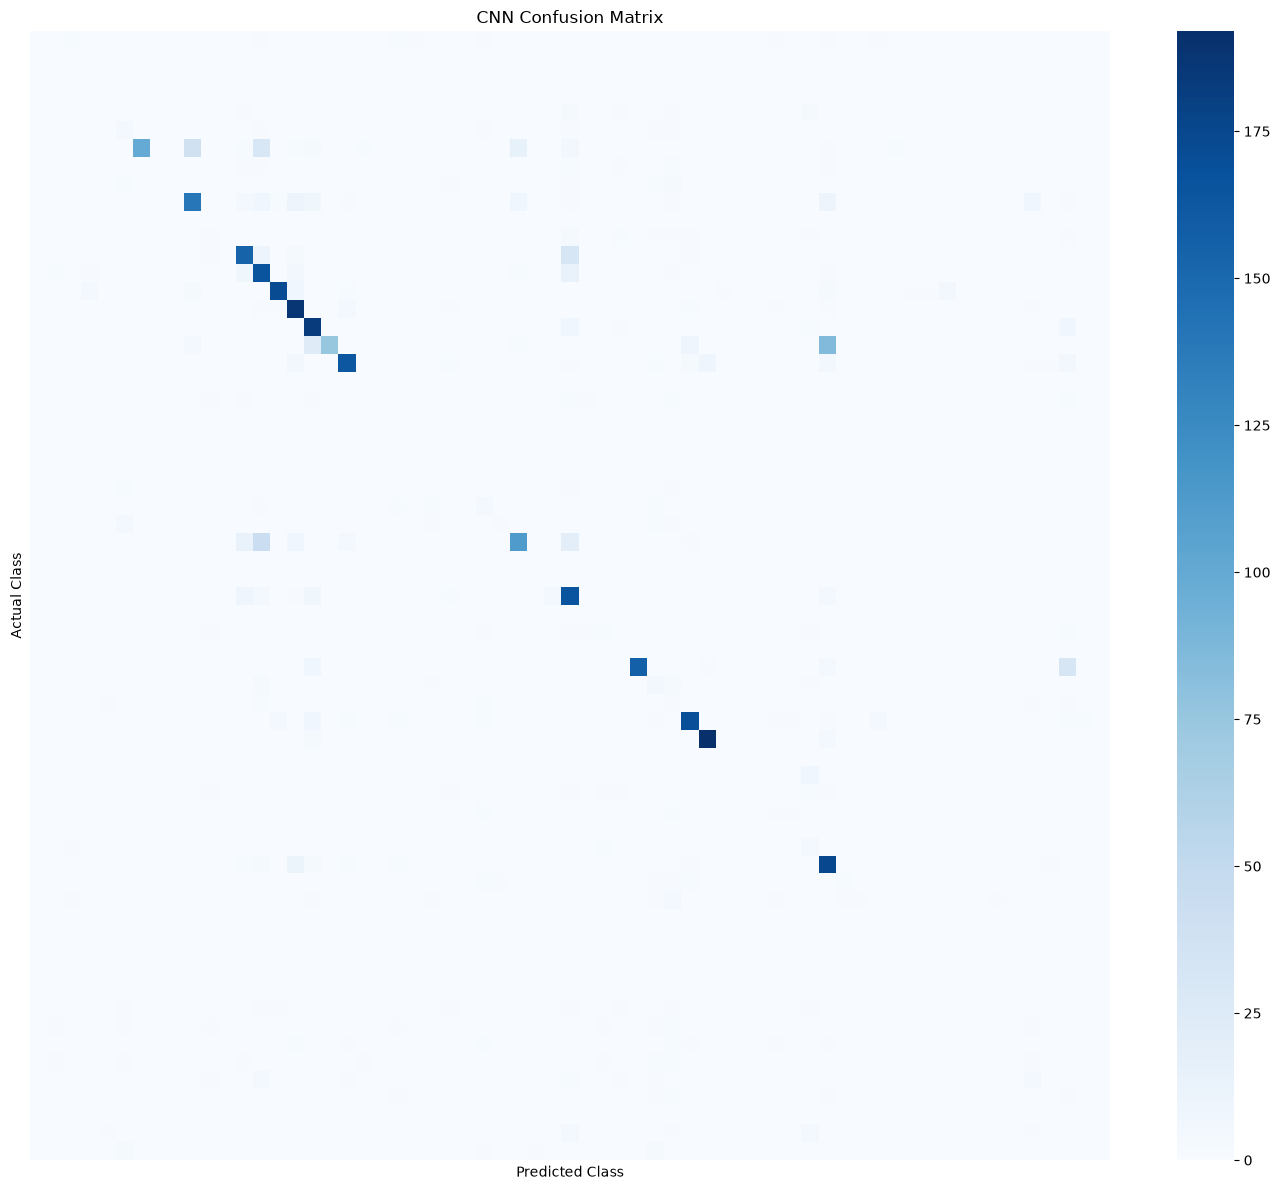

In [17]:

cnn_cm = None

if cnn_predictions is not None:
    cnn_cm = confusion_matrix(
        cnn_true_labels,
        cnn_predictions,
    )

    print("CNN CONFUSION MATRIX")
    print("Shape:", cnn_cm.shape)

    # For 82 classes, an annotated heatmap is too crowded.
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cnn_cm,
        cmap="Blues",
        xticklabels=False,
        yticklabels=False,
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title("CNN Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("CNN CONFUSION MATRIX NOT AVAILABLE")


### CNN Normalized Confusion Matrix

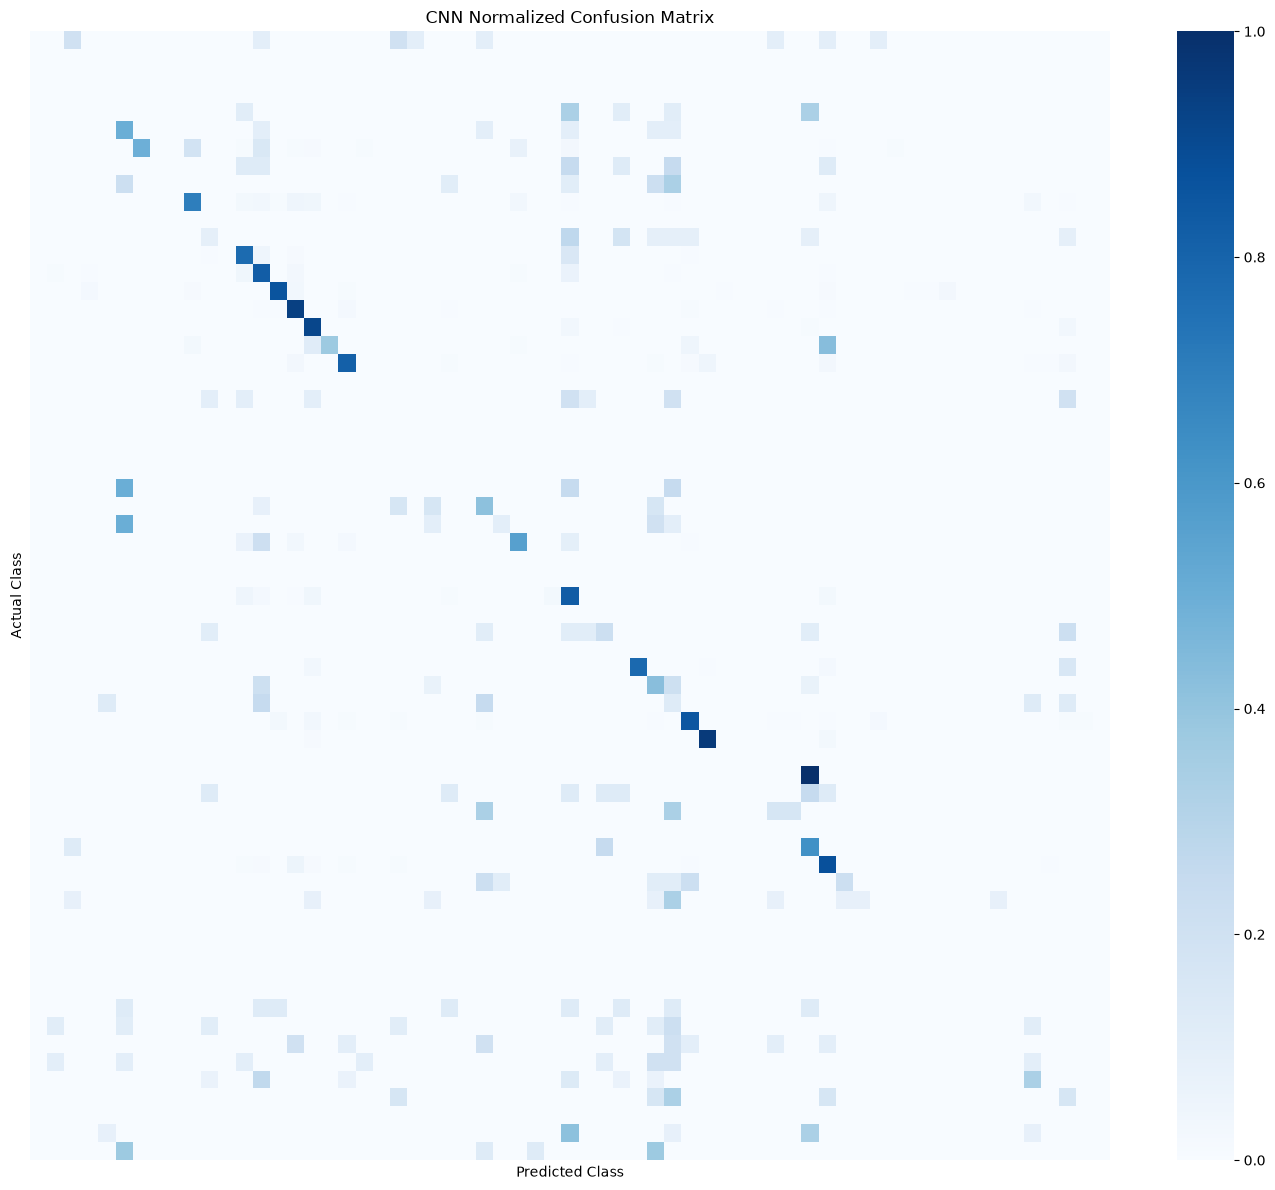

In [18]:

if cnn_cm is not None:
    row_totals = cnn_cm.sum(axis=1, keepdims=True)

    normalized_cm = np.divide(
        cnn_cm,
        row_totals,
        out=np.zeros_like(cnn_cm, dtype=float),
        where=row_totals != 0,
    )

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        normalized_cm,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=False,
        yticklabels=False,
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title("CNN Normalized Confusion Matrix")
    plt.tight_layout()
    plt.show()


### CNN Best & Worst Classes

In [19]:

if not cnn_report_df.empty:
    class_only_report = cnn_report_df.loc[
        [
            name for name in cnn_class_to_index
            if name in cnn_report_df.index
        ]
    ].copy()

    print("BEST 10 CNN CLASSES")
    display(
        class_only_report
        .sort_values("f1-score", ascending=False)
        .head(10)
    )

    print("WORST 10 CNN CLASSES")
    display(
        class_only_report
        .sort_values("f1-score", ascending=True)
        .head(10)
    )


BEST 10 CNN CLASSES


,precision,recall,f1-score,support
Cherry_leaf,0.950276,0.860,0.902887,200.0
Cucumber,0.905556,0.815,0.857895,200.0
Corn_Gray_leaf_spot,0.773663,0.940,0.848758,200.0
Corn_leaf_blight,0.740891,0.915,0.818792,200.0
Carrot,0.777778,0.770,0.773869,200.0
Broccoli,0.752688,0.700,0.725389,200.0
Tomato_leaf_late_blight,0.619403,0.830,0.709402,200.0
Cauliflower,0.595668,0.825,0.691824,200.0
Strawberry_leaf,0.811594,0.560,0.662722,200.0
Blueberry_leaf,1.000000,0.495,0.662207,200.0


WORST 10 CNN CLASSES


,precision,recall,f1-score,support
Apple_Scab_Leaf,0.0,0.0,0.0,10.0
Apple_leaf,0.0,0.0,0.0,0.0
Apple_rust_leaf,0.0,0.0,0.0,0.0
Bean,0.0,0.0,0.0,0.0
Bell_pepper_leaf,0.0,0.0,0.0,0.0
Bell_pepper_leaf_spot,0.0,0.0,0.0,9.0
Brinjal,0.0,0.0,0.0,9.0
Bottle_Gourd,0.0,0.0,0.0,8.0
Cabbage,0.0,0.0,0.0,0.0
Capsicum,0.0,0.0,0.0,11.0


### CNN Prediction Confidence

CNN PREDICTION SUMMARY
Predictions: 3,252
Correct: 2,344
Incorrect: 908


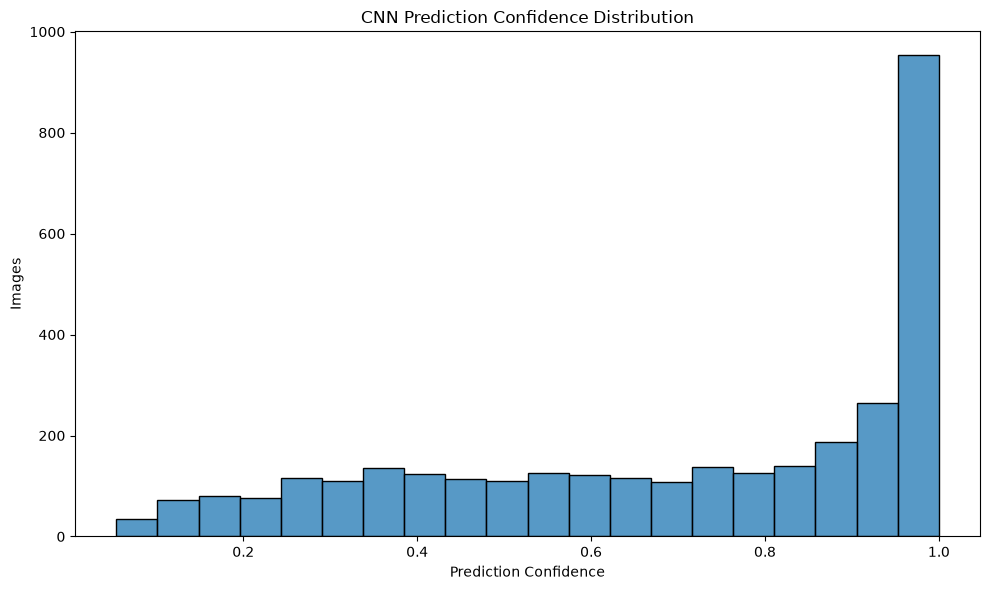

In [20]:

cnn_prediction_df = pd.DataFrame()

if cnn_predictions is not None:
    reverse_map = {
        idx: name
        for name, idx in cnn_class_to_index.items()
    }

    cnn_prediction_df = pd.DataFrame({
        "Image_Path": compatible_test_df["Resolved_Eval_Path"].tolist(),
        "Actual_Class": [
            reverse_map.get(int(i), "Unknown")
            for i in cnn_true_labels
        ],
        "Predicted_Class": [
            reverse_map.get(int(i), "Unknown")
            for i in cnn_predictions
        ],
        "Confidence": np.max(
            cnn_probabilities,
            axis=1
        ),
    })

    cnn_prediction_df["Correct"] = (
        cnn_prediction_df["Actual_Class"]
        == cnn_prediction_df["Predicted_Class"]
    )

    print("CNN PREDICTION SUMMARY")
    print("Predictions:", f"{len(cnn_prediction_df):,}")
    print("Correct:", f"{cnn_prediction_df['Correct'].sum():,}")
    print("Incorrect:", f"{(~cnn_prediction_df['Correct']).sum():,}")

    plt.figure(figsize=(10, 6))
    sns.histplot(
        cnn_prediction_df["Confidence"],
        bins=20,
        kde=False,
    )
    plt.xlabel("Prediction Confidence")
    plt.ylabel("Images")
    plt.title("CNN Prediction Confidence Distribution")
    plt.tight_layout()
    plt.show()


### CNN Evaluation Results Save

In [21]:

cnn_metrics_df = pd.DataFrame([{
    "Model": "CNN",
    "Test_Images": len(compatible_test_df),
    "Accuracy": cnn_evaluation["accuracy"],
    "Precision_Macro": cnn_precision,
    "Recall_Macro": cnn_recall,
    "F1_Macro": cnn_f1,
}])

cnn_metrics_path = EVALUATION_ROOT / "cnn_metrics.csv"
cnn_report_path = EVALUATION_ROOT / "cnn_classification_report.csv"
cnn_predictions_path = EVALUATION_ROOT / "cnn_predictions.csv"

cnn_metrics_df.to_csv(cnn_metrics_path, index=False)

if not cnn_report_df.empty:
    cnn_report_df.to_csv(cnn_report_path)

if not cnn_prediction_df.empty:
    cnn_prediction_df.to_csv(cnn_predictions_path, index=False)

print("CNN RESULTS SAVED")
print(cnn_metrics_path)
print(cnn_report_path)
print(cnn_predictions_path)


CNN RESULTS SAVED
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Model_Evaluation_Results\cnn_metrics.csv
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Model_Evaluation_Results\cnn_classification_report.csv
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Model_Evaluation_Results\cnn_predictions.csv


### Load YOLO Classification Model

In [22]:
# ============================================================
# YOLO MODEL DISCOVERY
# ============================================================

YOLO_MODEL_CANDIDATES = [
    YOLO_MODEL_ROOT
    / "classification_runs"
    / "smartagrivision_yolo_classification_cpu"
    / "weights"
    / "best.pt",

    YOLO_MODEL_ROOT
    / "classification_runs"
    / "smartagrivision_yolo_classification_cpu"
    / "weights"
    / "last.pt",

    YOLO_MODEL_ROOT / "best.pt",
    YOLO_MODEL_ROOT / "last.pt",

    YOLO_MODEL_ROOT
    / "training_runs"
    / "smartagrivision_yolo"
    / "weights"
    / "best.pt",

    YOLO_MODEL_ROOT
    / "training_runs"
    / "smartagrivision_yolo"
    / "weights"
    / "last.pt",
]


print("YOLO MODEL CANDIDATES")

for p in YOLO_MODEL_CANDIDATES:
    print(f"{p} | Exists: {p.exists()}")


# ------------------------------------------------------------
# Select best available model
# ------------------------------------------------------------

yolo_model_path = None

for p in YOLO_MODEL_CANDIDATES:
    if p.exists() and p.is_file():
        yolo_model_path = p
        break


print("\nYOLO MODEL SEARCH")
print(
    "Selected:",
    yolo_model_path if yolo_model_path else "None"
)




YOLO MODEL SEARCH
Selected: None
YOLO evaluation will be skipped safely.


### Locate YOLO Classification Dataset

In [30]:

# YOLO MODEL DISCOVERY


YOLO_MODEL_CANDIDATES = [
    YOLO_MODEL_ROOT
    / "classification_runs"
    / "smartagrivision_yolo_classification_cpu"
    / "weights"
    / "best.pt",

    YOLO_MODEL_ROOT
    / "classification_runs"
    / "smartagrivision_yolo_classification_cpu"
    / "weights"
    / "last.pt",

    YOLO_MODEL_ROOT / "best.pt",
    YOLO_MODEL_ROOT / "last.pt",

    YOLO_MODEL_ROOT
    / "training_runs"
    / "smartagrivision_yolo"
    / "weights"
    / "best.pt",

    YOLO_MODEL_ROOT
    / "training_runs"
    / "smartagrivision_yolo"
    / "weights"
    / "last.pt",
]


print("YOLO MODEL CANDIDATES")

for p in YOLO_MODEL_CANDIDATES:
    print(f"{p} | Exists: {p.exists()}")


# ------------------------------------------------------------
# Select best available model
# ------------------------------------------------------------

yolo_model_path = None

for p in YOLO_MODEL_CANDIDATES:
    if p.exists() and p.is_file():
        yolo_model_path = p
        break


print("\nYOLO MODEL SEARCH")
print(
    "Selected:",
    yolo_model_path if yolo_model_path else "None"
)


# ------------------------------------------------------------
# Load YOLO model
# ------------------------------------------------------------

yolo_model = None

if yolo_model_path is not None:

    try:
        yolo_model = YOLO(str(yolo_model_path))

        print("YOLO MODEL LOADED")
        print("Model path:", yolo_model_path)
        print(
            "Task:",
            getattr(yolo_model, "task", "unknown")
        )

    except Exception as error:

        print("YOLO MODEL LOAD FAILED")
        print(type(error).__name__)
        print(error)

else:

    print("YOLO MODEL NOT FOUND")
    print(
        "YOLO evaluation will be skipped safely."
    )

YOLO MODEL CANDIDATES
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\classification_runs\smartagrivision_yolo_classification_cpu\weights\best.pt | Exists: True
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\classification_runs\smartagrivision_yolo_classification_cpu\weights\last.pt | Exists: True
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\best.pt | Exists: False
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\last.pt | Exists: False
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\training_runs\smartagrivision_yolo\weights\best.pt | Exists: False
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Models\training_runs\smartagrivision_yol

### YOLO Classification Evaluation

In [31]:

yolo_metrics = {
    "Top1_Accuracy": np.nan,
    "Top5_Accuracy": np.nan,
}

if yolo_model is not None and yolo_dataset_path is not None:
    try:
        yolo_results = yolo_model.val(
            data=str(yolo_dataset_path),
            split="test",
            imgsz=IMAGE_SIZE,
            batch=EVAL_BATCH_SIZE,
            device="cpu" if not gpu_devices else 0,
            verbose=True,
        )

        # Classification models expose top1/top5 metrics.
        if hasattr(yolo_results, "top1"):
            yolo_metrics["Top1_Accuracy"] = float(yolo_results.top1)

        if hasattr(yolo_results, "top5"):
            yolo_metrics["Top5_Accuracy"] = float(yolo_results.top5)

        # Some Ultralytics versions store these in results.results_dict.
        results_dict = getattr(yolo_results, "results_dict", {})

        for key, target in [
            ("metrics/accuracy_top1", "Top1_Accuracy"),
            ("metrics/accuracy_top5", "Top5_Accuracy"),
        ]:
            if np.isnan(yolo_metrics[target]) and key in results_dict:
                yolo_metrics[target] = float(results_dict[key])

        print("YOLO CLASSIFICATION EVALUATION COMPLETED")

    except Exception as error:
        print("YOLO CLASSIFICATION EVALUATION FAILED")
        print(error)
else:
    print("YOLO CLASSIFICATION EVALUATION SKIPPED SAFELY")

print("YOLO METRICS")
for key, value in yolo_metrics.items():
    print(
        key + ":",
        "N/A" if pd.isna(value) else f"{value:.4f}"
    )


Ultralytics 8.4.115  Python-3.11.15 torch-2.13.0+cpu CPU (Intel Core i5-6200U 2.30GHz)
YOLO11n-cls summary (fused): 47 layers, 1,631,066 parameters, 0 gradients, 3.2 GFLOPs
train: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Classification_Dataset\train... found 91926 images in 82 classes  
val: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Classification_Dataset\val... found 13044 images in 82 classes  
ERROR test: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Classification_Dataset\test... found 13140 images in 81 classes (requires 82 classes, not 81)
test: Fast image access  (ping: 0.10.0 ms, read: 997.3975.4 MB/s, size: 359.9 KB)
test: Scanning E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\YOLO_Classification_Dataset\test... 13140 images, 0 corrupt: 100% ━━━━━━━━━━━━ 13

### CNN vs YOLO Performance Comparison

In [32]:

comparison_rows = []

if not pd.isna(cnn_evaluation["accuracy"]):
    comparison_rows.append({
        "Model": "CNN",
        "Accuracy": cnn_evaluation["accuracy"],
        "Precision": cnn_precision,
        "Recall": cnn_recall,
        "F1": cnn_f1,
    })

if not pd.isna(yolo_metrics["Top1_Accuracy"]):
    comparison_rows.append({
        "Model": "YOLO",
        "Accuracy": yolo_metrics["Top1_Accuracy"],
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
    })

model_comparison_df = pd.DataFrame(comparison_rows)

print("MODEL PERFORMANCE COMPARISON")
display(model_comparison_df)

if not model_comparison_df.empty:
    model_comparison_df.to_csv(
        EVALUATION_ROOT / "model_performance_comparison.csv",
        index=False,
    )


MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1
0,CNN,0.720787,0.257009,0.234492,0.2262
1,YOLO,0.963318,NaN,NaN,NaN


### Final Evaluation Summary

In [33]:

summary = {
    "CNN_Model": str(cnn_model_path) if cnn_model_path else None,
    "CNN_Test_Images": int(len(compatible_test_df)),
    "CNN_Accuracy": None if pd.isna(cnn_evaluation["accuracy"]) else float(cnn_evaluation["accuracy"]),
    "CNN_Precision_Macro": None if pd.isna(cnn_precision) else float(cnn_precision),
    "CNN_Recall_Macro": None if pd.isna(cnn_recall) else float(cnn_recall),
    "CNN_F1_Macro": None if pd.isna(cnn_f1) else float(cnn_f1),
    "YOLO_Model": str(yolo_model_path) if yolo_model_path else None,
    "YOLO_Top1_Accuracy": None if pd.isna(yolo_metrics["Top1_Accuracy"]) else float(yolo_metrics["Top1_Accuracy"]),
    "YOLO_Top5_Accuracy": None if pd.isna(yolo_metrics["Top5_Accuracy"]) else float(yolo_metrics["Top5_Accuracy"]),
}

summary_path = EVALUATION_ROOT / "final_evaluation_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4)

print("FINAL EVALUATION SUMMARY")
display(pd.DataFrame([summary]))
print("Saved:", summary_path)


FINAL EVALUATION SUMMARY


,CNN_Model,CNN_Test_Images,CNN_Accuracy,CNN_Precision_Macro,CNN_Recall_Macro,CNN_F1_Macro,YOLO_Model,YOLO_Top1_Accuracy,YOLO_Top5_Accuracy
0,E:\programming languages\DJANGO PROJECT\SmartA...,3252,0.720787,0.257009,0.234492,0.2262,E:\programming languages\DJANGO PROJECT\SmartA...,0.963318,0.995662


Saved: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Model_Evaluation_Results\final_evaluation_summary.json


### Final Safety Status

In [34]:

print("FINAL EVALUATION STATUS")
print("Metadata available:", metadata_path is not None)
print("CNN model available:", cnn_model is not None)
print("CNN metadata test images:", len(compatible_test_df))
print("CNN evaluation available:", cnn_predictions is not None)
print("YOLO model available:", yolo_model is not None)
print("YOLO classification dataset available:", yolo_dataset_path is not None)
print("Evaluation output:", EVALUATION_ROOT)

print("\nEVALUATION COMPLETED SAFELY")


FINAL EVALUATION STATUS
Metadata available: True
CNN model available: True
CNN metadata test images: 3252
CNN evaluation available: True
YOLO model available: True
YOLO classification dataset available: True
Evaluation output: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Model_Evaluation_Results

EVALUATION COMPLETED SAFELY
